# Compare trained models

Loads training summaries and evaluation outputs for a session, aggregates key metrics across models, and plots overall comparisons plus validation trajectories.

In [1]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package to ensure using the local code.
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [2]:
import json
import re
from pathlib import Path
from typing import Dict, Iterable, List
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- PATH SETUP ---
current_dir = Path.cwd()
if (current_dir / "training_runs").exists():
    RUNS_ROOT = current_dir / "training_runs"
elif (current_dir.parent / "training_runs").exists():
    RUNS_ROOT = current_dir.parent / "training_runs"
else:
    raise FileNotFoundError(f"Could not find 'training_runs' in {current_dir} or parent.")

print(f"Runs Root: {RUNS_ROOT.resolve()}")

# --- CONFIGURATION ---
SESSION_TAG = None  # Leave None to auto-pick latest
EXCLUDE_EXPERIMENTS: List[str] = [] 

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 5)

# --- DISCOVERY LOGIC ---
def discover_runs():
    runs = []
    
    # Regex to capture the Session Prefix (Tag + Timestamp) and the Model Name
    # Matches: "prefix_YYYYMMDD-HHMMSS_modelname"
    # Group 1: Session Prefix (e.g., resampled_20251206-162829)
    # Group 2: Model Suffix (e.g., custom_cnn, efficientnet_b1)
    name_pattern = re.compile(r"^(.*_\d{8}-\d{6})_(.+)$")

    for path in RUNS_ROOT.iterdir():
        if not path.is_dir():
            continue
            
        cfg_path = path / "config.json"
        if not cfg_path.exists():
            continue

        # 1. Determine Session Prefix and Experiment Name from Folder Name
        match = name_pattern.match(path.name)
        if match:
            session_prefix = match.group(1)
            folder_suffix = match.group(2)
        else:
            # Fallback for folders without timestamps (legacy support)
            if "_" in path.name:
                session_prefix, folder_suffix = path.name.rsplit("_", 1)
            else:
                session_prefix, folder_suffix = path.name, path.name

        # 2. Try to get a cleaner display name from config.json
        model_name = None
        try:
            cfg = json.loads(cfg_path.read_text())
            model_name = cfg.get("model_name")
        except Exception:
            pass
        
        # Use config model_name if available, otherwise use the folder suffix
        experiment = model_name if model_name else folder_suffix

        runs.append({
            "path": path,
            "session_prefix": session_prefix,
            "experiment": experiment,
            "mtime": path.stat().st_mtime,
        })
    return runs

def resolve_session_tag() -> str:
    if SESSION_TAG:
        return SESSION_TAG
    runs = discover_runs()
    if not runs:
        raise FileNotFoundError("No training runs found.")
    
    # Find the latest run based on file modification time
    latest_run = max(runs, key=lambda r: r["mtime"])
    return latest_run["session_prefix"]

def list_experiments(session_prefix: str):
    runs = discover_runs()
    # Filter for runs belonging to this session
    exps = sorted({r["experiment"] for r in runs if r["session_prefix"] == session_prefix})
    
    if not exps:
        available = sorted({r["session_prefix"] for r in runs})
        raise FileNotFoundError(f"No experiments for session '{session_prefix}'. Found: {available}")
        
    return [exp for exp in exps if exp not in EXCLUDE_EXPERIMENTS]

# --- EXECUTION ---
SESSION_PREFIX = resolve_session_tag()
EXPERIMENTS = list_experiments(SESSION_PREFIX)

print(f"Session:     {SESSION_PREFIX}")
print(f"Experiments: {EXPERIMENTS}")

# --- PLOTTING SETUP ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 170,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.facecolor": "#f7f9fb",
    "axes.edgecolor": "#e0e6ed",
    "grid.alpha": 0.3,
})
sns.despine(left=False, bottom=False)

Runs Root: /home/tim/repos/ipeo-hurricane-damage-detection/training_runs
Session:     resampled_20251206-162829
Experiments: ['convnext_small', 'convnext_tiny', 'custom_cnn', 'efficientnet_b1', 'efficientnet_b2', 'resnet18', 'resnet34', 'resnet50']


<Figure size 1088x816 with 0 Axes>

## Load runs and build comparison table

Experiments are auto-discovered from `training_runs` for the chosen session; set `EXCLUDE_EXPERIMENTS` to omit any.
Reads configs, training summaries, and evaluation metrics for each experiment, plus keeps per-epoch histories for trajectory plots.

In [3]:
def load_run(exp_name: str, session_prefix: str):
    run_dir = RUNS_ROOT / f"{session_prefix}_{exp_name}"
    if not run_dir.exists():
        print(f"Skipping missing run_dir: {run_dir}")
        return None, None

    cfg_path = run_dir / "config.json"
    train_summary_path = run_dir / "train_summary.json"
    eval_metrics_path = run_dir / "eval_metrics.json"

    if not cfg_path.exists() or not train_summary_path.exists():
        print(f"Missing config or train_summary for {run_dir}, skipping.")
        return None, None

    cfg = json.loads(cfg_path.read_text())
    train_summary = json.loads(train_summary_path.read_text())
    eval_metrics = json.loads(eval_metrics_path.read_text()) if eval_metrics_path.exists() else {}

    history = train_summary.get("history") or []

    row = {
        "experiment": exp_name,
        "run_dir": str(run_dir),
        "model": cfg.get("model_name"),
        "image_size": cfg.get("image_size"),
        "batch_size": cfg.get("batch_size"),
        "epochs_ran": len(history),
        "best_epoch": train_summary.get("best_epoch"),
        "best_val_macro_f1": train_summary.get("best_metric"),
        "temperature": eval_metrics.get("temperature"),
    }

    for split in ("val_raw", "val_calibrated", "test_raw", "test_calibrated"):
        metrics = eval_metrics.get(split) or {}
        for k, v in metrics.items():
            row[f"{split}_{k}"] = v

    return row, history


def build_palette(labels: Iterable[str]) -> Dict[str, tuple]:
    labels = list(labels)
    base = sns.color_palette("tab10")
    if len(labels) > len(base):
        base = sns.color_palette("husl", len(labels))
    return {label: base[i % len(base)] for i, label in enumerate(labels)}


def annotate_bars(ax, fmt: str = "{:.3f}"):
    for container in ax.containers:
        if not len(container):
            continue
        labels = [fmt.format(v) if v is not None else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type="edge", padding=3, fontsize=9, color="#1f2933")


rows = []
history_frames = []
for exp in EXPERIMENTS:
    row, history = load_run(exp, SESSION_PREFIX)
    if row:
        rows.append(row)
    if history:
        hist_df = pd.DataFrame(history)
        hist_df["experiment"] = exp
        history_frames.append(hist_df)

comparison_df = pd.DataFrame(rows)
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("experiment").reset_index(drop=True)

history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
if not history_df.empty:
    history_df = history_df.sort_values(["experiment", "epoch"]).reset_index(drop=True)

comparison_df

,experiment,run_dir,model,image_size,batch_size,epochs_ran,best_epoch,best_val_macro_f1,temperature,val_raw_accuracy,val_raw_macro_precision,val_raw_macro_recall,val_raw_macro_f1,val_raw_brier,val_raw_ece,val_calibrated_accuracy,val_calibrated_macro_precision,val_calibrated_macro_recall,val_calibrated_macro_f1,val_calibrated_brier,val_calibrated_ece,test_raw_accuracy,test_raw_macro_precision,test_raw_macro_recall,test_raw_macro_f1,test_raw_brier,test_raw_ece,test_calibrated_accuracy,test_calibrated_macro_precision,test_calibrated_macro_recall,test_calibrated_macro_f1,test_calibrated_brier,test_calibrated_ece
0,convnext_small,/home/tim/repos/ipeo-hurricane-damage-detectio...,convnext_small,256,32,40,27,0.99946,0.79084,0.9995,0.99930,0.99961,0.99946,0.00123,0.02543,0.9995,0.99930,0.99961,0.99946,0.00066,0.00977,0.9980,0.99776,0.99776,0.99776,0.00185,0.02588,0.9980,0.99776,0.99776,0.99776,0.00132,0.01043
1,convnext_tiny,/home/tim/repos/ipeo-hurricane-damage-detectio...,convnext_tiny,256,48,45,32,0.99891,0.80555,0.9990,0.99891,0.99891,0.99891,0.00166,0.02381,0.9990,0.99891,0.99891,0.99891,0.00117,0.00953,0.9965,0.99556,0.99663,0.99609,0.00382,0.02176,0.9965,0.99556,0.99663,0.99609,0.00346,0.00677
2,custom_cnn,/home/tim/repos/ipeo-hurricane-damage-detectio...,custom_cnn,256,96,47,34,0.99133,0.79306,0.9920,0.98960,0.99316,0.99133,0.00775,0.02443,0.9920,0.98960,0.99316,0.99133,0.00699,0.01080,0.9910,0.98959,0.99030,0.98994,0.00684,0.02598,0.9910,0.98959,0.99030,0.98994,0.00627,0.01230
3,efficientnet_b1,/home/tim/repos/ipeo-hurricane-damage-detectio...,efficientnet_b1,240,48,26,13,0.99946,0.79117,0.9995,0.99961,0.99930,0.99946,0.00095,0.02413,0.9995,0.99961,0.99930,0.99946,0.00045,0.00935,0.9975,0.99667,0.99775,0.99721,0.00206,0.02471,0.9975,0.99667,0.99775,0.99721,0.00162,0.01024
4,efficientnet_b2,/home/tim/repos/ipeo-hurricane-damage-detectio...,efficientnet_b2,260,36,25,12,0.99946,0.78230,0.9995,0.99961,0.99930,0.99946,0.00106,0.02680,0.9995,0.99961,0.99930,0.99946,0.00046,0.01023,0.9970,0.99629,0.99701,0.99665,0.00279,0.02582,0.9970,0.99629,0.99701,0.99665,0.00233,0.01003
5,resnet18,/home/tim/repos/ipeo-hurricane-damage-detectio...,resnet18,256,64,24,11,0.99837,0.78461,0.9985,0.99791,0.99883,0.99837,0.00223,0.02650,0.9985,0.99791,0.99883,0.99837,0.00157,0.01036,0.9960,0.99482,0.99625,0.99553,0.00341,0.02648,0.9960,0.99482,0.99625,0.99553,0.00291,0.01059
6,resnet34,/home/tim/repos/ipeo-hurricane-damage-detectio...,resnet34,256,48,24,11,0.99837,0.79241,0.9985,0.99884,0.99791,0.99837,0.00232,0.02651,0.9985,0.99884,0.99791,0.99837,0.00167,0.01053,0.9960,0.99625,0.99480,0.99552,0.00330,0.02682,0.9960,0.99625,0.99480,0.99552,0.00282,0.01034
7,resnet50,/home/tim/repos/ipeo-hurricane-damage-detectio...,resnet50,256,32,38,25,1.00000,0.78068,1.0000,1.00000,1.00000,1.00000,0.00078,0.02631,1.0000,1.00000,1.00000,1.00000,0.00014,0.00989,0.9980,0.99705,0.99849,0.99777,0.00170,0.02734,0.9980,0.99705,0.99849,0.99777,0.00115,0.01091


## Overview table

Quick glance at the key metrics pulled from evaluation outputs.

In [8]:
if comparison_df.empty:
    print("No runs to plot. Ensure SESSION_TAG matches your training/evaluation outputs.")
else:
    metric_cols = [col for col in ("test_calibrated_macro_f1", "test_raw_macro_f1") if col in comparison_df.columns]
    ece_cols = [col for col in ("test_calibrated_ece", "test_raw_ece") if col in comparison_df.columns]
    display_cols = [
        "experiment",
        "model",
        "image_size",
        "batch_size",
        "epochs_ran",
        "best_epoch",
        "best_val_macro_f1",
    ]
    display_cols += metric_cols + ece_cols
    if "temperature" in comparison_df.columns:
        display_cols.append("temperature")

    overview = comparison_df[display_cols]
    if metric_cols:
        overview = overview.sort_values(metric_cols[0], ascending=False)
    overview.reset_index(drop=True)

overview

,experiment,model,image_size,batch_size,epochs_ran,best_epoch,best_val_macro_f1,test_calibrated_macro_f1,test_raw_macro_f1,test_calibrated_ece,test_raw_ece,temperature
7,resnet50,resnet50,256,32,38,25,1.00000,0.99777,0.99777,0.01091,0.02734,0.78068
0,convnext_small,convnext_small,256,32,40,27,0.99946,0.99776,0.99776,0.01043,0.02588,0.79084
3,efficientnet_b1,efficientnet_b1,240,48,26,13,0.99946,0.99721,0.99721,0.01024,0.02471,0.79117
4,efficientnet_b2,efficientnet_b2,260,36,25,12,0.99946,0.99665,0.99665,0.01003,0.02582,0.78230
1,convnext_tiny,convnext_tiny,256,48,45,32,0.99891,0.99609,0.99609,0.00677,0.02176,0.80555
5,resnet18,resnet18,256,64,24,11,0.99837,0.99553,0.99553,0.01059,0.02648,0.78461
6,resnet34,resnet34,256,48,24,11,0.99837,0.99552,0.99552,0.01034,0.02682,0.79241
2,custom_cnn,custom_cnn,256,96,47,34,0.99133,0.98994,0.98994,0.01230,0.02598,0.79306


## Comparison plots

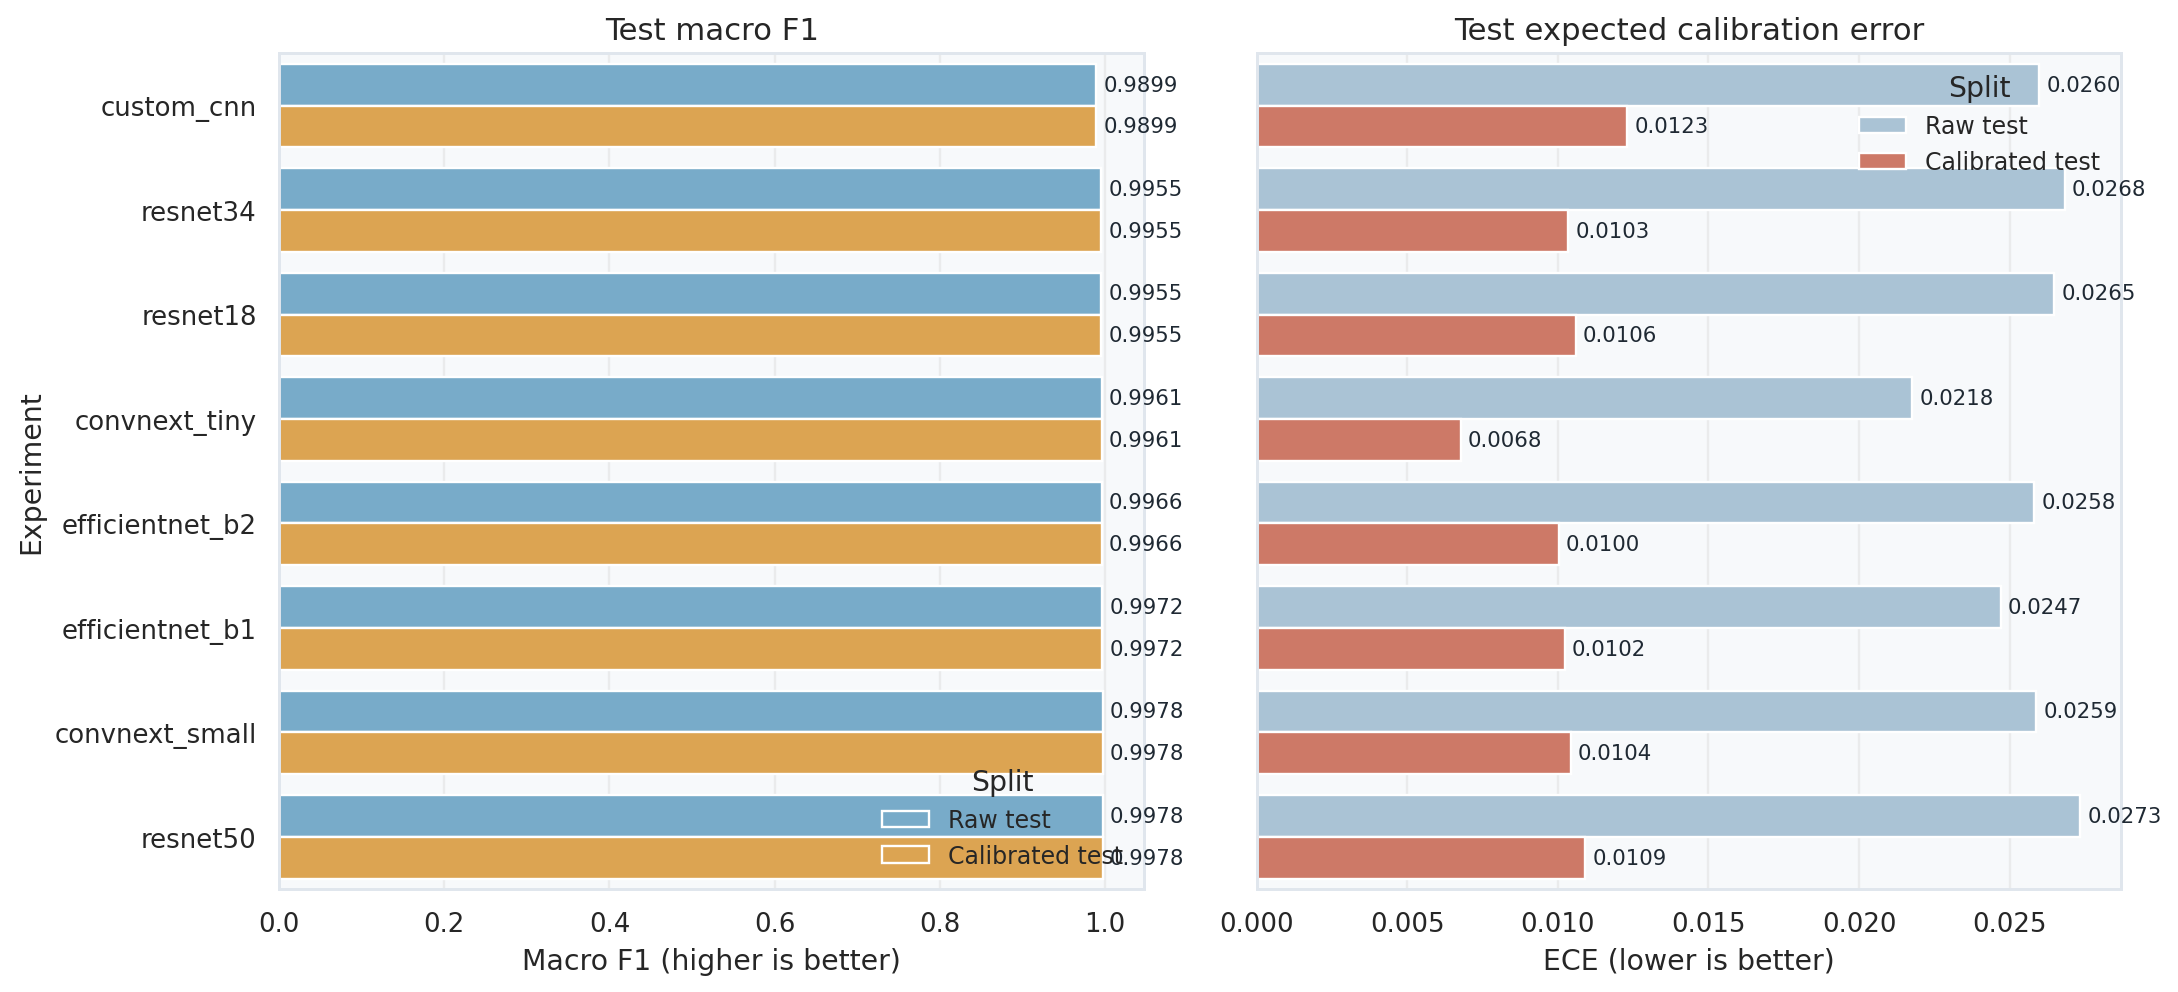

/tmp/ipykernel_12012/574601776.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


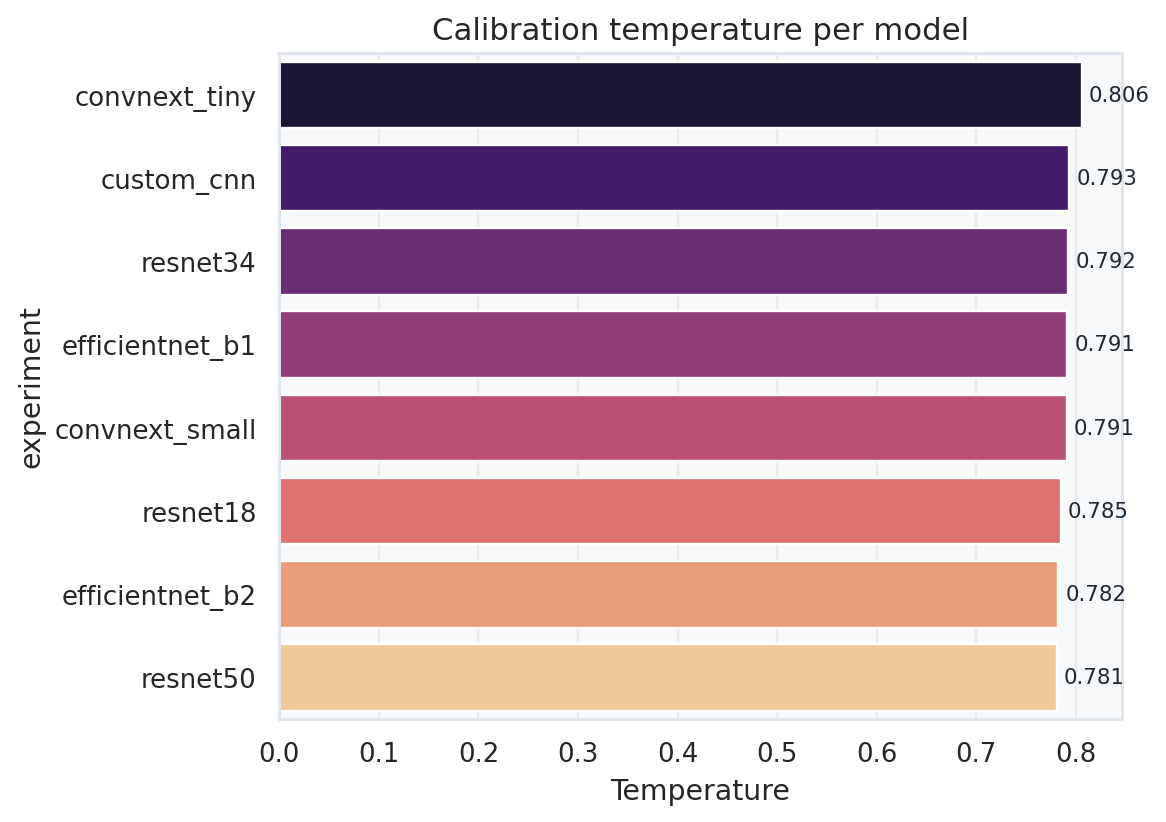

In [5]:
if comparison_df.empty:
    print("No runs to plot. Ensure SESSION_TAG matches your training/evaluation outputs.")
else:
    f1_cols = [c for c in ("test_raw_macro_f1", "test_calibrated_macro_f1") if c in comparison_df.columns]
    ece_cols = [c for c in ("test_raw_ece", "test_calibrated_ece") if c in comparison_df.columns]

    if f1_cols:
        f1_long = comparison_df.melt(
            id_vars=["experiment"],
            value_vars=f1_cols,
            var_name="split",
            value_name="macro_f1",
        )
        split_labels = {
            "test_raw_macro_f1": "Raw test",
            "test_calibrated_macro_f1": "Calibrated test",
        }
        f1_long["split"] = f1_long["split"].map(split_labels)
        f1_long = f1_long.sort_values(["macro_f1", "experiment"], ascending=[True, True])

        fig, axes = plt.subplots(
            1,
            2 if ece_cols else 1,
            figsize=(13 if ece_cols else 9, 6),
            sharey=True,
        )
        if not isinstance(axes, (list, np.ndarray)):
            axes = [axes]

        sns.barplot(
            data=f1_long,
            x="macro_f1",
            y="experiment",
            hue="split",
            palette=["#6baed6", "#f3a83b"],
            ax=axes[0],
        )
        axes[0].set_title("Test macro F1")
        axes[0].set_xlabel("Macro F1 (higher is better)")
        axes[0].set_ylabel("Experiment")
        annotate_bars(axes[0], fmt="{:.4f}")
        axes[0].legend(title="Split", loc="lower right", frameon=False)

        if ece_cols:
            ece_long = comparison_df.melt(
                id_vars=["experiment"],
                value_vars=ece_cols,
                var_name="split",
                value_name="ece",
            )
            ece_labels = {
                "test_raw_ece": "Raw test",
                "test_calibrated_ece": "Calibrated test",
            }
            ece_long["split"] = ece_long["split"].map(ece_labels)
            ece_long = ece_long.sort_values(["ece", "experiment"], ascending=[False, True])

            sns.barplot(
                data=ece_long,
                x="ece",
                y="experiment",
                hue="split",
                palette=["#a3c4dc", "#de6e56"],
                ax=axes[1],
            )
            axes[1].set_title("Test expected calibration error")
            axes[1].set_xlabel("ECE (lower is better)")
            axes[1].set_ylabel("")
            annotate_bars(axes[1], fmt="{:.4f}")
            axes[1].legend(title="Split", loc="upper right", frameon=False)

        plt.tight_layout()
        plt.show()

    if "temperature" in comparison_df.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        temp_sorted = comparison_df.sort_values("temperature", ascending=False)
        sns.barplot(
            data=temp_sorted,
            x="temperature",
            y="experiment",
            palette="magma",
            ax=ax,
        )
        ax.set_title("Calibration temperature per model")
        ax.set_xlabel("Temperature")
        annotate_bars(ax, fmt="{:.3f}")
        plt.tight_layout()
        plt.show()

## Validation metric trajectories

Macro precision/recall/F1 and calibration error over epochs for each experiment. Best epoch per metric is marked on each line.

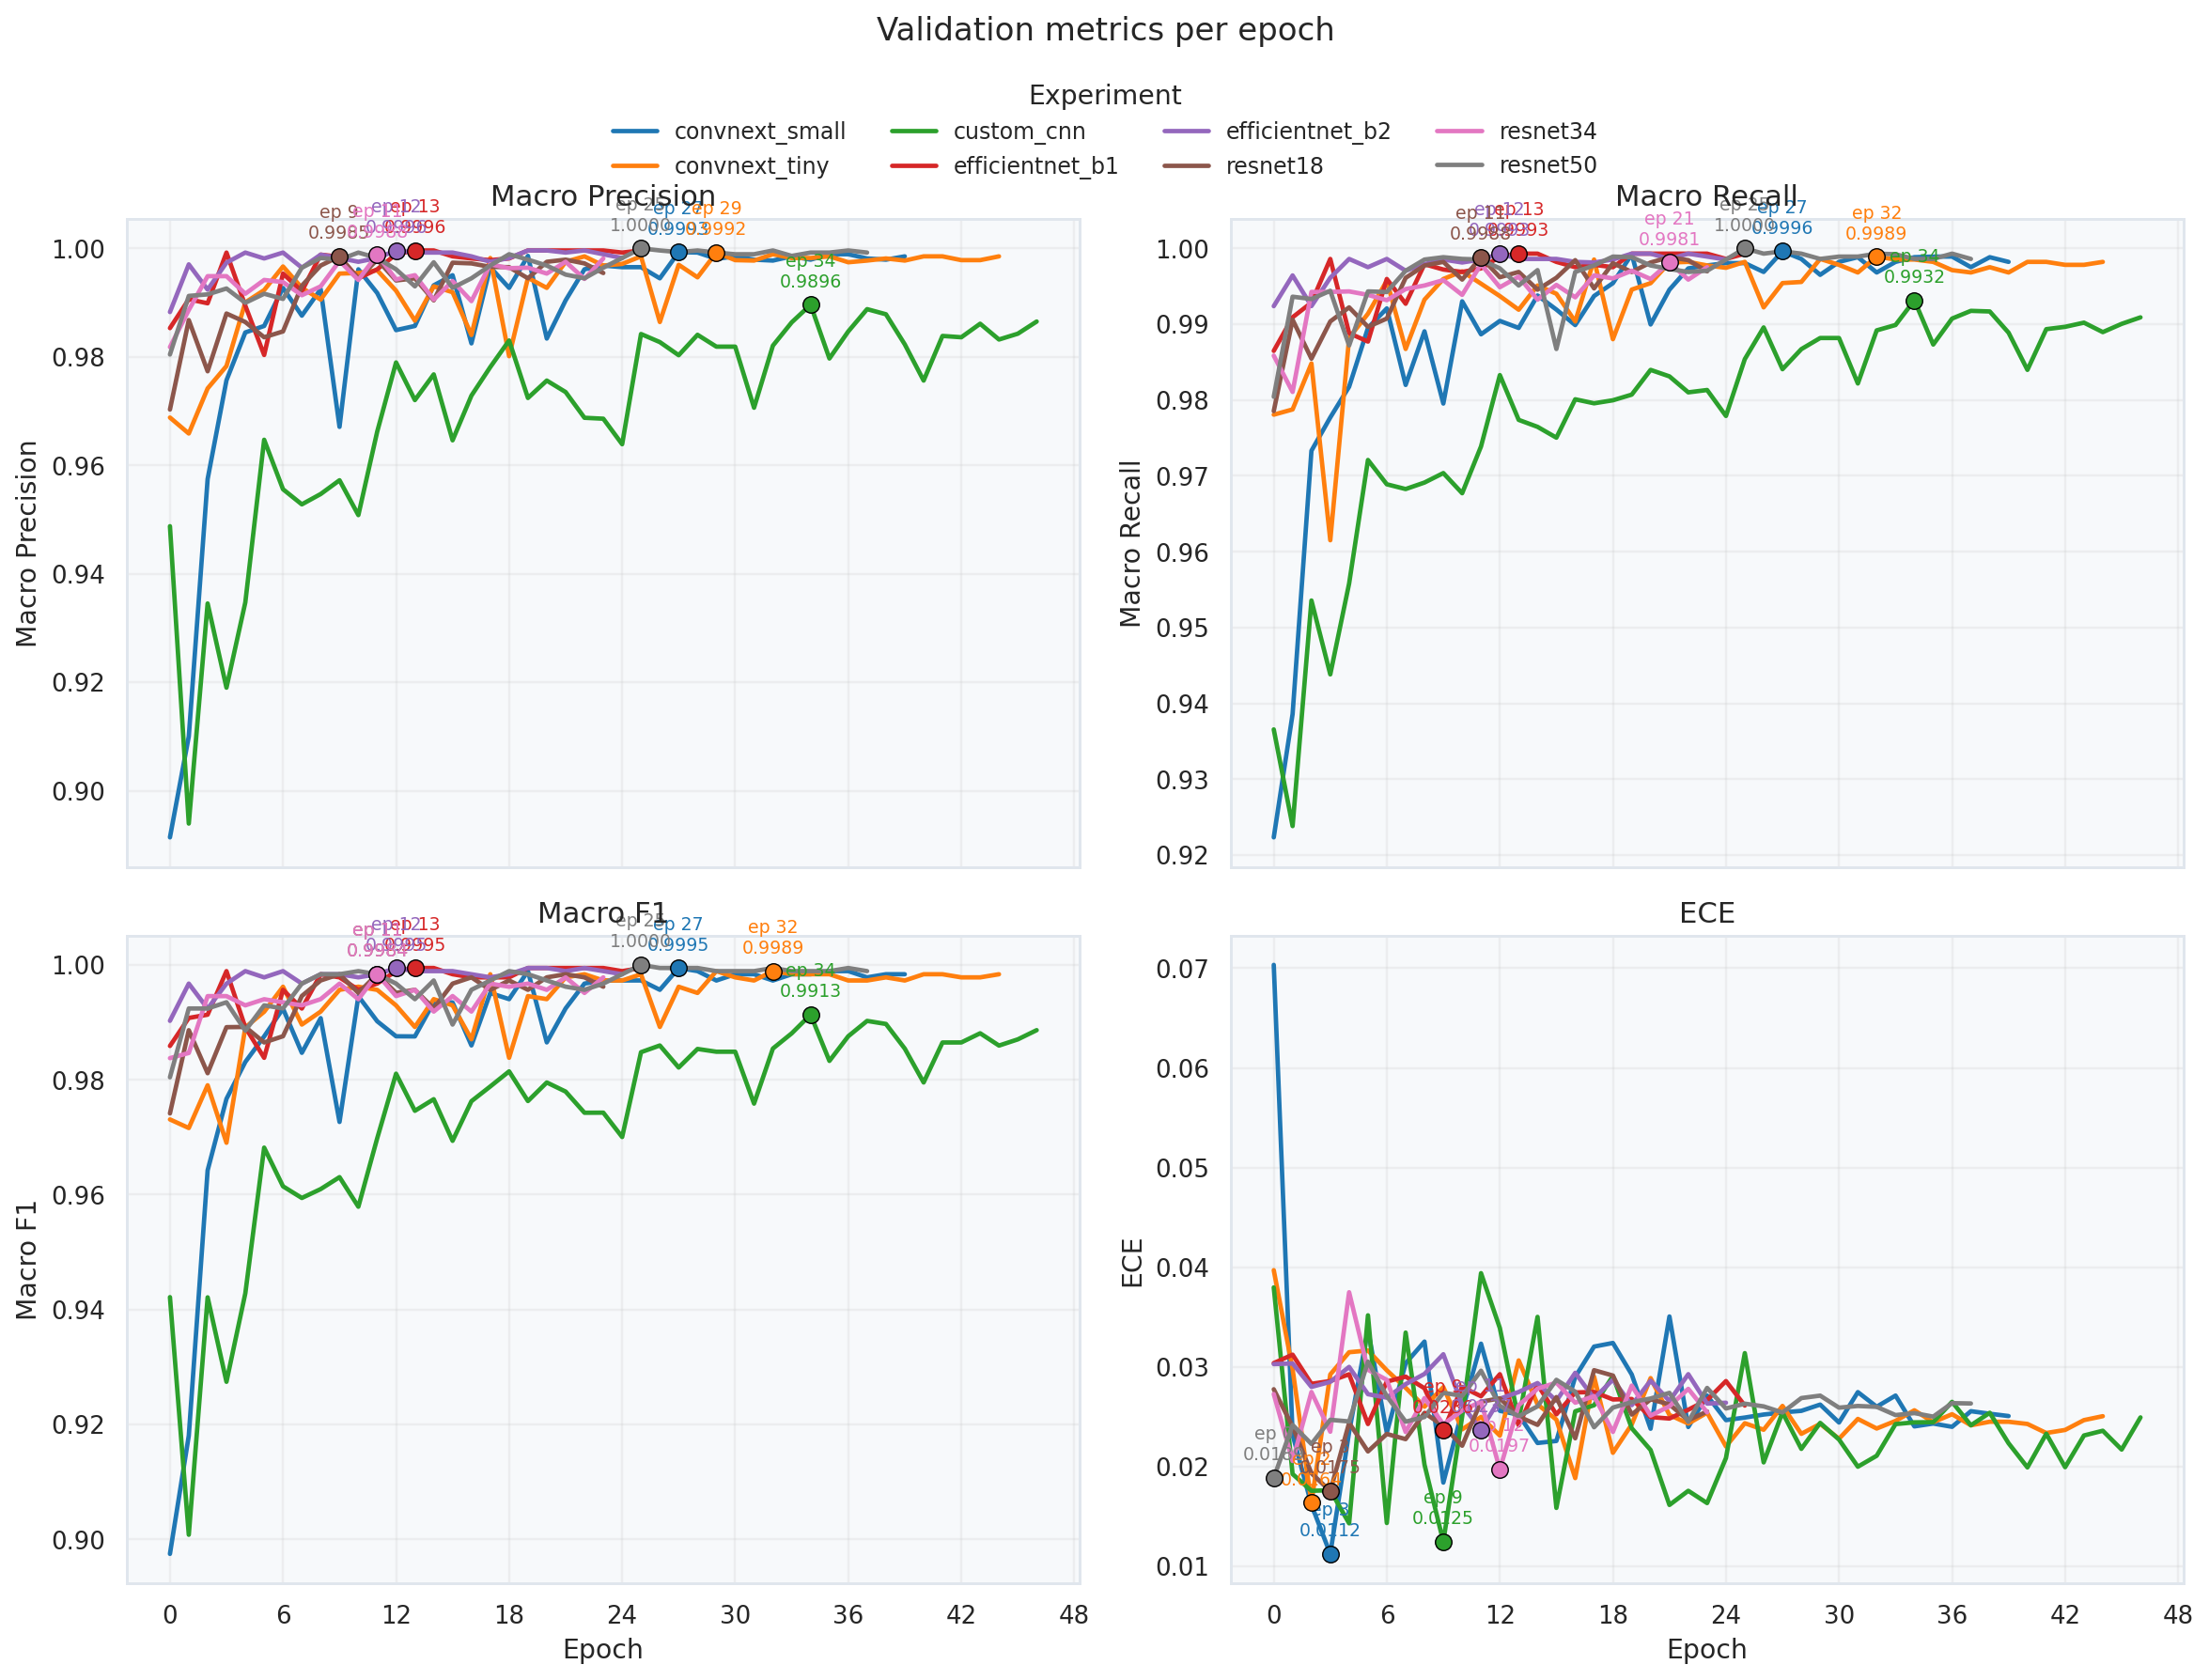

In [9]:
if history_df.empty:
    print("No training histories found for trajectories.")
else:
    metric_specs = [
        ("val/macro_precision", "Macro Precision", True),
        ("val/macro_recall", "Macro Recall", True),
        ("val/macro_f1", "Macro F1", True),
        ("val/ece", "ECE", False),
    ]

    experiments_present = history_df["experiment"].unique().tolist()
    palette = build_palette(experiments_present)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    for ax, (metric, label, higher_is_better) in zip(axes, metric_specs):
        if metric not in history_df.columns:
            ax.set_visible(False)
            continue

        metric_df = history_df.dropna(subset=[metric])
        if metric_df.empty:
            ax.set_visible(False)
            continue

        sns.lineplot(
            data=metric_df,
            x="epoch",
            y=metric,
            hue="experiment",
            palette=palette,
            linewidth=2,
            ax=ax,
            legend=False,
        )

        for exp, exp_df in metric_df.groupby("experiment"):
            if exp_df.empty:
                continue
            selector = exp_df[metric].idxmax() if higher_is_better else exp_df[metric].idxmin()
            best_row = exp_df.loc[selector]
            ax.scatter(
                best_row["epoch"],
                best_row[metric],
                color=palette[exp],
                s=55,
                edgecolor="black",
                linewidth=0.6,
                zorder=5,
            )
            ax.annotate(
                f"ep {int(best_row['epoch'])}\n{best_row[metric]:.4f}",
                (best_row["epoch"], best_row[metric]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
                color=palette[exp],
            )

        ax.set_title(label)
        ylabel = label if higher_is_better else f"{label}"
        ax.set_ylabel(ylabel)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(alpha=0.25)

    for ax in axes:
        if ax.get_visible():
            ax.set_xlabel("Epoch")

    legend_handles = [Line2D([0], [0], color=palette[exp], lw=2) for exp in experiments_present]
    fig.legend(
        legend_handles,
        experiments_present,
        title="Experiment",
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.suptitle("Validation metrics per epoch", y=1.05)
    plt.tight_layout()
    plt.show()